# Logistic Regression with an invented example / Vizualization of the Hypotheis Function in 3D

**Data creation**

X.shape: (26, 2)


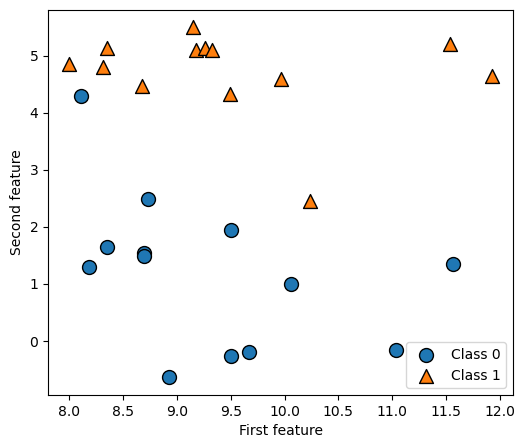

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import check_random_state, shuffle

def make_blobs(centers=2, random_state=4, n_samples=30):
    g = check_random_state(random_state)

    # fixed setup (2 centers, 2 features, std=1)
    centers = g.uniform(-10, 10, size=(centers, centers))
    neg = int(n_samples/2)
    pos = n_samples-neg
    n = [neg, pos]  # 30 samples split evenly

    X = np.vstack([centers[i] + g.normal(scale=1.0, size=(n[i], 2)) for i in range(2)])
    y = np.array([i for i in range(2) for _ in range(n[i])])

    X, y = shuffle(X, y, random_state=g)
    return X, y

# a carefully hand-designed dataset 
def make_forge():
    X, y = make_blobs(centers=2, random_state=4, n_samples=30)
    y[np.array([7, 27])] = 0 # color two points blue 
    mask = np.ones(len(X), dtype=bool) # make a boolean array with all trues
    mask[np.array([0, 1, 5, 26])] = 0 # remove this
    X, y = X[mask], y[mask]
    return X, y

def plotScatter(X, y, figsize):
    plt.figure(figsize=figsize) 
    markers = ['o', '^']
    for i, class_value in enumerate(np.unique(y)):
        plt.scatter(
            X[y == class_value, 0],
            X[y == class_value, 1],
            marker=markers[i % len(markers)],
            s=100,                    # 👈 größere Punkte
            edgecolor='black',        # 👈 schwarzer Rand
            label=f"Class {class_value}"
        )

    plt.legend(loc=4)
    plt.xlabel("First feature")
    plt.ylabel("Second feature")
    return plt

X, y = make_forge()
ax = plotScatter(X, y, (6, 5))
print("X.shape:", X.shape)



**Perform Logistic Regression and visualize**

In [2]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression() # instantiation of the learning algorithm
clf.fit(X, y)              # train with all data
clf

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [3]:
print(clf.intercept_)
print(clf.coef_)

[-11.09738878]
[[0.6728714  1.53137914]]


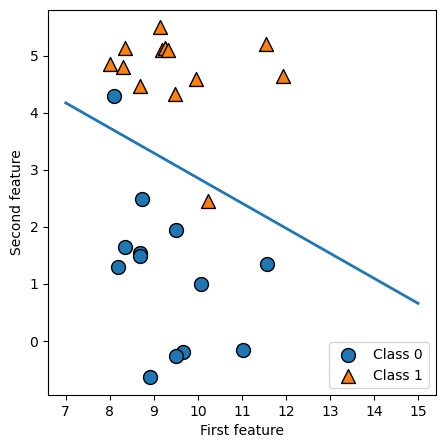

In [4]:
# Draw a decision boundary
def plotBoundary(clf, ax):
   th0 = clf.intercept_[0]
   th1, th2 = clf.coef_.T
   # Calculate the intercept and slope of the decision boundary.
   # how can we go from 3d-error to 2d-decision boundary ?
   # we set 0 = th0+th1*x1+th2*x2 and resolve by x2
   yintercept = -th0/th2
   slope = -th1/th2
   line_x = np.array([7,15]) # min and max x
   line_y = line_x*slope+yintercept
   ax.plot(line_x,line_y,linewidth=2)

ax = plotScatter(X, y, figsize=(5, 5))   # plot training points
plotBoundary(clf,ax)                     # plot boundary


**Making Predictions**<br>
Make some predictions with the already trained model *clf* according the following instructions
* Use the model to make a new prediction for the point $[9.5,1]$. 
* Visualize the location of the examined data point in the plot. Please see https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.axes.Axes.scatter.html
* In LogisticRegression there is a function *predict_proba*. Call the function an try interpreting the values
* Find a second point very close to the line and compare the probabilities


In [5]:
from matplotlib.colors import ListedColormap
# Define a basic plot function for reuse
def plotScatter3D(X, y, figsize=(8, 6)):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    cmap_custom = ListedColormap(['blue', 'green'])
    ax.scatter(X[:, 0], X[:, 1], y, c=y, cmap=cmap_custom, label='Data')
    ax.set_title("The data")
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
    ax.set_zlabel("Class")
    return ax

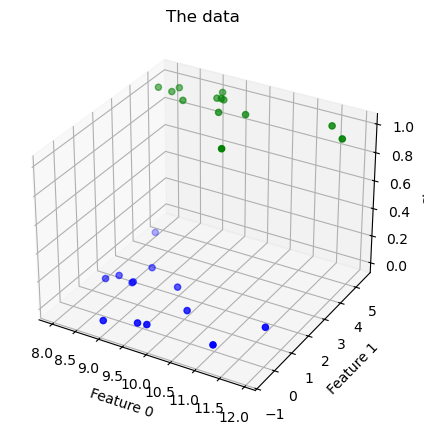

In [6]:
ax = plotScatter3D(X, y, figsize=(5, 5)) 

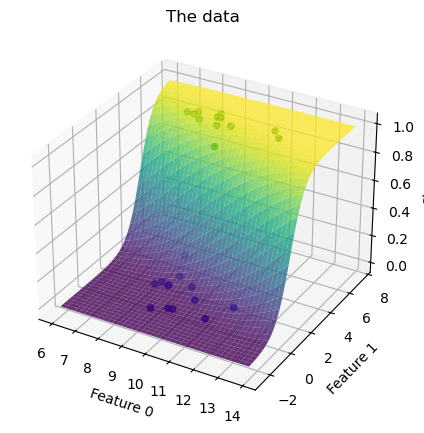

In [7]:
# Logistic function / sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Hypothesenfunktion für logistische Regression
def hypothesis(intercept, coef, x1, x2):
    z = intercept + coef[0]*x1 + coef[1]*x2
    return sigmoid(z)

def plotSurface3D(ax, clf, X):
    x1_vals = np.linspace(np.min(X[:, 0])-2, np.max(X[:, 0])+2, 40)
    x2_vals = np.linspace(np.min(X[:, 1])-2, np.max(X[:, 1])+2, 40)
    x1_mesh, x2_mesh = np.meshgrid(x1_vals, x2_vals)

    # Berechne die Hypothesenwerte für jedes Gitterpunkt
    hypothesis_values = hypothesis(clf.intercept_[0], clf.coef_[0], x1_mesh, x2_mesh)
    ax.plot_surface(x1_mesh, x2_mesh, hypothesis_values, cmap='viridis', alpha=0.8)

ax = plotScatter3D(X, y, figsize=(5, 5)) 
plotSurface3D(ax,clf,X)
plt.show()


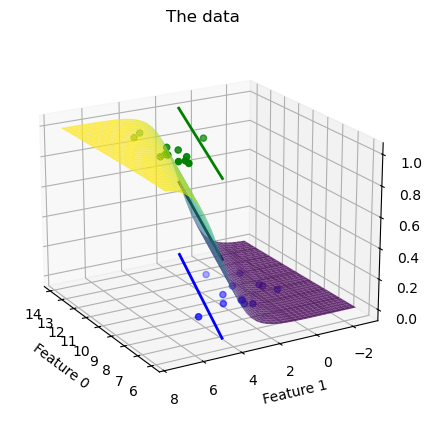

In [8]:
#now also show the decision border
def plotBoundary3D(clf, ax, minx, maxx):
   th0 = clf.intercept_[0]
   th1, th2 = clf.coef_.T
   # Calculate the intercept and slope of the decision boundary.
   # how can we go from 3d-error to 2d-decision boundary ?
   # we set 0 = th0+th1*x1+th2*x2 and resolve by x2
   yintercept = -th0/th2
   slope = -th1/th2
   line_x = np.array([minx,maxx]) # min and max x
   line_y = line_x*slope+yintercept
   ax.plot3D(line_x,line_y,line_y*0+0.5, c='black', linewidth=2)
   ax.plot3D(line_x,line_y,line_y*0, c='blue', linewidth=2)
   ax.plot3D(line_x,line_y,line_y*0+1, c='green', linewidth=2)

ax = plotScatter3D(X, y, figsize=(5, 5)) 
plotSurface3D(ax,clf,X)
plotBoundary3D(clf, ax, np.min(X[:, 0])-2, np.max(X[:, 0])+2) 
ax.view_init(elev=20, azim=150, roll=0)
plt.show()


In [ ]:
LogisticRegression?

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(penalty=None, C=1) # instantiation of the learning algorithm
clf.fit(X, y)              # train with all data
ax = plotScatter(X, y, figsize=(5, 5))   # plot training points
plotBoundary(clf,ax)  